In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from src.python import tech_colors, ssp_colors
from sklearn.linear_model import LinearRegression
import os

# Set LaTeX style
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.2,
    'lines.linewidth': 1.5,
})


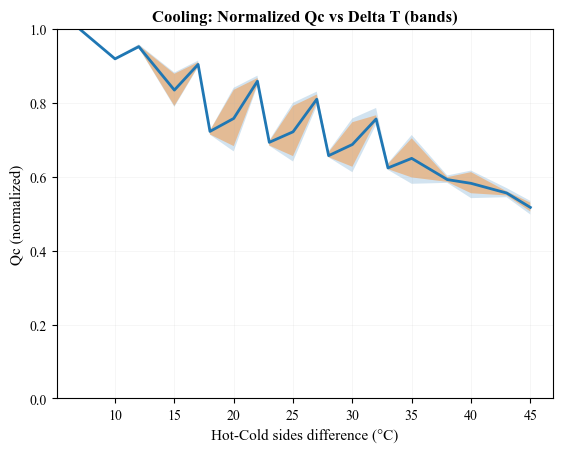

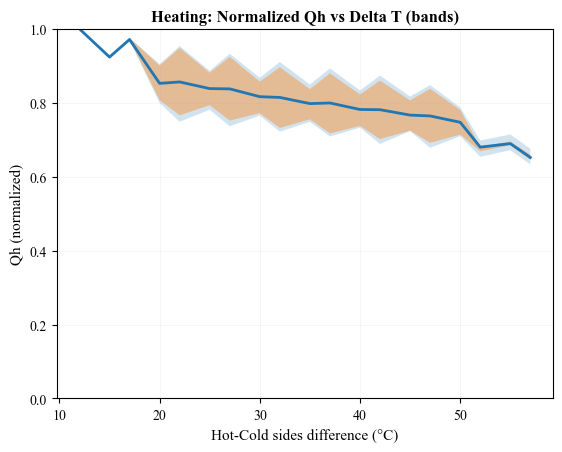

In [3]:
file_path = "data/inputs/HP/WG60HP.xlsx"

# ----------------------------
# 1) READ SHEETS
# ----------------------------
df_cool = pd.read_excel(file_path, sheet_name="WG60HP_cooling")
df_heat = pd.read_excel(file_path, sheet_name="WG60_heating")


# ----------------------------
# 2) SELECT COLUMNS
# ----------------------------
cool_cols = [
    "Model",
    "LWT",
    "Condenser [°C]",
    "Qc [kW]",
    "EER [kW/kW]",
]

heat_cols = [
    "Model",
    "LWT [°C]",
    "Evaportator Entering [°C]",
    "Qh [kW]",
    "COP [kW/kW]",
]

df_cool = df_cool[cool_cols].copy()
df_heat = df_heat[heat_cols].copy()


# ----------------------------
# 3) RENAME TEMPERATURES + COP/EER
# ----------------------------
df_cool.rename(
    columns={
        "LWT": "cold_side_temp_C",
        "Condenser [°C]": "hot_side_temp_C",
        "EER [kW/kW]": "COP_cooling",
        "Qc [kW]": "Qc_kW",
    },
    inplace=True,
)

df_heat.rename(
    columns={
        "LWT [°C]": "hot_side_temp_C",
        "Evaportator Entering [°C]": "cold_side_temp_C",
        "COP [kW/kW]": "COP_heating",
        "Qh [kW]": "Qh_kW",
    },
    inplace=True,
)


# ----------------------------
# 4) DROP NON-NUMERIC ROWS
# ----------------------------
numeric_cols_cool = ["cold_side_temp_C", "hot_side_temp_C", "Qc_kW", "COP_cooling"]
numeric_cols_heat = ["hot_side_temp_C", "cold_side_temp_C", "Qh_kW", "COP_heating"]

df_cool[numeric_cols_cool] = df_cool[numeric_cols_cool].apply(pd.to_numeric, errors="coerce")
df_heat[numeric_cols_heat] = df_heat[numeric_cols_heat].apply(pd.to_numeric, errors="coerce")

df_cool = df_cool.dropna(subset=numeric_cols_cool)
df_heat = df_heat.dropna(subset=numeric_cols_heat)

df_cool['Delta_T'] = df_cool['hot_side_temp_C'] - df_cool['cold_side_temp_C']
df_heat['Delta_T'] = df_heat['hot_side_temp_C'] - df_heat['cold_side_temp_C']

# ----------------------------
# 5) NORMALIZE BY DESIGN POWER (PER MODEL)
# ----------------------------
def normalize_by_design(df, model_col, power_col):
    # take maximum power per model as design reference
    design_power = df.groupby(model_col)[power_col].max().rename("design_power")
    df = df.merge(design_power, on=model_col)
    df[f"{power_col}_norm"] = df[power_col] / df["design_power"]
    return df.drop(columns=["design_power"])

df_cool = normalize_by_design(df_cool, "Model", "Qc_kW")
df_heat = normalize_by_design(df_heat, "Model", "Qh_kW")


# ----------------------------
# 6) DELTA_T
# ----------------------------
df_cool["Delta_T"] = df_cool["hot_side_temp_C"] - df_cool["cold_side_temp_C"]
df_heat["Delta_T"] = df_heat["hot_side_temp_C"] - df_heat["cold_side_temp_C"]

# ----------------------------
# 7) BAND PLOT FUNCTION
# ----------------------------
def band_plot(ax, x, y, label):
    """
    Plots median line with 25-75 and 10-90 bands.
    """
    # Sort by x
    data = pd.DataFrame({"x": x, "y": y}).dropna()
    data = data.sort_values("x")

    stats = data.agg(
        x_mid=("x", "mean"),
        y_med=("y", "median"),
        y_p25=("y", lambda s: np.quantile(s, 0.25)),
        y_p75=("y", lambda s: np.quantile(s, 0.75)),
        y_p10=("y", lambda s: np.quantile(s, 0.10)),
        y_p90=("y", lambda s: np.quantile(s, 0.90)),
    ).dropna()

    ax.fill_between(stats["x_mid"], stats["y_p10"], stats["y_p90"], alpha=0.2)
    ax.fill_between(stats["x_mid"], stats["y_p25"], stats["y_p75"], alpha=0.4)
    ax.plot(stats["x_mid"], stats["y_med"], label=label, linewidth=2)
# ----------------------------
# 8) BAND PLOTS WITHOUT BINNING
# ----------------------------
def band_plot_no_bin(ax, x, y, label):
    data = pd.DataFrame({"x": x, "y": y}).dropna()
    unique_x = np.sort(data["x"].unique())

    x_list, y_med, y_p25, y_p75, y_p10, y_p90 = [], [], [], [], [], []

    for xv in unique_x:
        yv = data.loc[data["x"] == xv, "y"]
        if len(yv) < 2:
            continue
        x_list.append(xv)
        y_med.append(np.median(yv))
        y_p25.append(np.quantile(yv, 0.25))
        y_p75.append(np.quantile(yv, 0.75))
        y_p10.append(np.quantile(yv, 0.10))
        y_p90.append(np.quantile(yv, 0.90))

    ax.fill_between(x_list, y_p10, y_p90, alpha=0.2)
    ax.fill_between(x_list, y_p25, y_p75, alpha=0.4)
    ax.plot(x_list, y_med, label=label, linewidth=2)

fig, ax = plt.subplots()
band_plot_no_bin(ax, df_cool["Delta_T"], df_cool["Qc_kW_norm"], "Cooling")
ax.set_xlabel("Hot-Cold sides difference (°C)")
ax.set_ylabel("Qc (normalized)")
ax.set_title("Cooling: Normalized Qc vs Delta T (bands)")
ax.grid(True)
ax.set_ylim(0, 1)
plt.show()

fig, ax = plt.subplots()
band_plot_no_bin(ax, df_heat["Delta_T"], df_heat["Qh_kW_norm"], "Heating")
ax.set_xlabel("Hot-Cold sides difference (°C)")
ax.set_ylabel("Qh (normalized)")
ax.set_title("Heating: Normalized Qh vs Delta T (bands)")
ax.grid(True)
ax.set_ylim(0, 1)
plt.show()


/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_51216/929512211.py:35: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_heat, _ = curve_fit(heating_model, x_heat, y_heat, p0=[0.5,10,5], maxfev=10000)
/var/folders/_8/5wkhjk491lg_89k0811g6vlm0000gn/T/ipykernel_51216/929512211.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_cool, _ = curve_fit(cooling_model, x_cool, y_cool, p0=[0.5,10,5], maxfev=10000)


Fitted heating parameter a: 0.6815, b: 17.1753, c: 5.0000
Fitted cooling parameter a: 0.7656, b: 5.0000, c: 5.0000


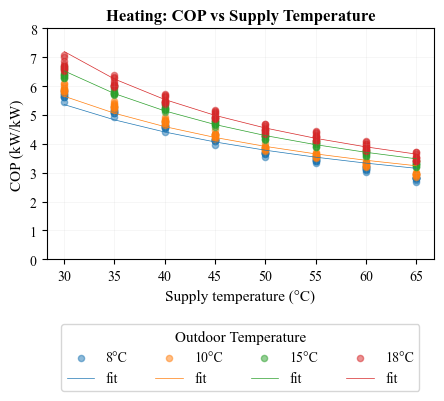

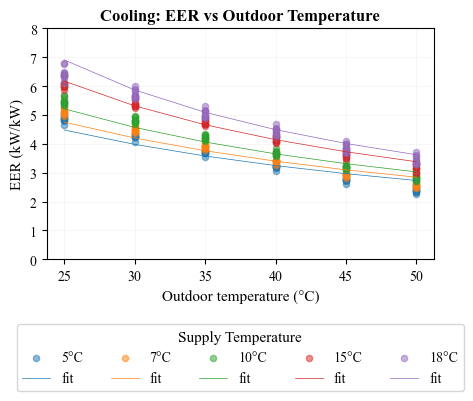

In [7]:
import numpy as np
from scipy.optimize import curve_fit

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# ----------------------------
# MODEL FUNCTIONS (GENERAL)
# ----------------------------
def generic_model(x, a, b, c):
    T_hot, T_cold = x
    return a * (T_hot + 273.15 + 5) / (T_hot - T_cold + b)

def heating_model(x, a, b, c):
    return generic_model(x, a, b, c)

def cooling_model(x, a, b, c):
    return generic_model(x, a, b, c) - 1
# ----------------------------
# Prepare data for fitting
# ----------------------------
x_heat = np.vstack((df_heat["hot_side_temp_C"].values, df_heat["cold_side_temp_C"].values))
y_heat = df_heat["COP_heating"].values

x_cool = np.vstack((df_cool["hot_side_temp_C"].values, df_cool["cold_side_temp_C"].values))
y_cool = df_cool["COP_cooling"].values

# ----------------------------
# Curve fitting
# ----------------------------curve_fit(heating_model, x_data, y_data, p0=[5, 10], maxfev=10000)
popt_heat, _ = curve_fit(heating_model, x_heat, y_heat, p0=[0.5,10,5], maxfev=10000)
popt_cool, _ = curve_fit(cooling_model, x_cool, y_cool, p0=[0.5,10,5], maxfev=10000)

a_heat, b_heat, c_heat = popt_heat
a_cool, b_cold, c_cold = popt_cool

print(f"Fitted heating parameter a: {a_heat:.4f}, b: {b_heat:.4f}, c: {c_heat:.4f}")
print(f"Fitted cooling parameter a: {a_cool:.4f}, b: {c_cold:.4f}, c: {c_cold:.4f}")

# ----------------------------
# HEATING: COP vs supply temperature grouped by outdoor temperature
# ----------------------------
fig, ax = plt.subplots(figsize = (5,3))

for t_out, grp in df_heat.groupby("cold_side_temp_C"):

    # plot data
    ax.scatter(
        grp["hot_side_temp_C"],
        grp["COP_heating"],
        label=f"{t_out}°C",
        s=20, alpha = 0.5
    )

    # plot fit line
    x_sorted = np.sort(grp["hot_side_temp_C"].values)
    y_fit = heating_model((x_sorted, np.full_like(x_sorted, t_out)), a_heat, b_heat, c_heat)
    ax.plot(x_sorted, y_fit, linestyle="-", linewidth=0.5, label=f"fit")

ax.set_xlabel("Supply temperature (°C)")
ax.set_ylabel("COP (kW/kW)")
ax.set_title("Heating: COP vs Supply Temperature")
ax.grid(True)
ax.legend(title="Outdoor Temperature", loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.6))
plt.ylim(0,8)
# plt.savefig('data/inputs/HP/COP.pdf')

plt.savefig('data/inputs/HP/COP.png',dpi = 600, bbox_inches='tight')
plt.show()


# ----------------------------
# COOLING: EER vs supply temperature grouped by outdoor temperature
# ----------------------------
fig, ax = plt.subplots(figsize = (5,3))

for t_out, grp in df_cool.groupby("cold_side_temp_C"):
    x_data = np.vstack((grp["hot_side_temp_C"].values, grp["cold_side_temp_C"].values))
    y_data = grp["COP_cooling"].values

    # plot data
    ax.scatter(
        grp["hot_side_temp_C"],
        grp["COP_cooling"],
        label=f"{t_out}°C",
        s=20, alpha = 0.5
    )

    # plot fit line
    x_sorted = np.sort(grp["hot_side_temp_C"].values)
    y_fit = cooling_model((x_sorted, np.full_like(x_sorted, t_out)), a_cool, b_cold, c_cold)
    ax.plot(x_sorted, y_fit, linestyle="-", linewidth=0.5, label=f"fit")

ax.set_xlabel("Outdoor temperature (°C)")
ax.set_ylabel("EER (kW/kW)")
ax.set_title("Cooling: EER vs Outdoor Temperature")
ax.grid(True)
ax.legend(title="Supply Temperature", loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.6))
plt.ylim(0,8)
plt.savefig('data/inputs/HP/EER.pdf')

plt.savefig('data/inputs/HP/EER.png',dpi = 600, bbox_inches='tight')

plt.show()


Figure saved to: data/inputs/boiler_efficiency.pdf


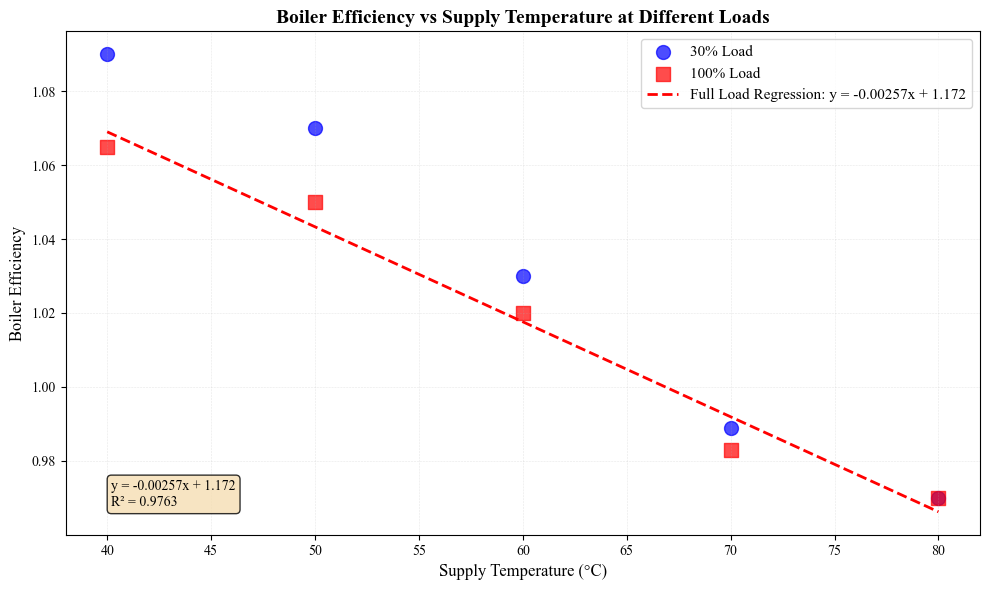


Regression Details (Full Load):
Coefficient (slope): -0.002570
Intercept: 1.171800
R² Score: 0.976305


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

# Data from the table
temperatures = np.array([40, 50, 60, 70, 80])  # Temperature (°C)
efficiency_30 = np.array([1.09, 1.07, 1.03, 0.989, 0.97])
efficiency_100 = np.array([1.065, 1.05, 1.02, 0.983, 0.97])

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot scatter points
ax.scatter(temperatures, efficiency_30, color='blue', s=100, 
           label='30% Load', alpha=0.7, marker='o')
ax.scatter(temperatures, efficiency_100, color='red', s=100, 
           label='100% Load', alpha=0.7, marker='s')

# Perform linear regression for full load (100%)
# Reshape temperatures for sklearn
X = temperatures.reshape(-1, 1)
y = efficiency_100

# Create and fit linear regression model
regressor = LinearRegression()
regressor.fit(X, y)

# Generate points for regression line
temp_range = np.linspace(temperatures.min(), temperatures.max(), 100)
predicted_efficiency = regressor.predict(temp_range.reshape(-1, 1))

# Plot regression line
ax.plot(temp_range, predicted_efficiency, color='red', 
        linestyle='--', linewidth=2, 
        label=f'Full Load Regression: y = {regressor.coef_[0]:.5f}x + {regressor.intercept_:.3f}')

# Add labels and title
ax.set_xlabel('Supply Temperature (°C)', fontsize=12)
ax.set_ylabel('Boiler Efficiency', fontsize=12)
ax.set_title('Boiler Efficiency vs Supply Temperature at Different Loads', 
             fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(fontsize=11, loc='best')

# Add equation text box
equation_text = f'y = {regressor.coef_[0]:.5f}x + {regressor.intercept_:.3f}\nR² = {regressor.score(X, y):.4f}'
ax.text(0.05, 0.05, equation_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Ensure directory exists
os.makedirs('data/inputs', exist_ok=True)

# Save figure as PDF
output_path = 'data/inputs/boiler_efficiency.pdf'
plt.tight_layout()
plt.savefig(output_path, format='pdf', dpi=300)
print(f"Figure saved to: {output_path}")

# Show the plot
plt.show()

# Print regression details
print("\nRegression Details (Full Load):")
print(f"Coefficient (slope): {regressor.coef_[0]:.6f}")
print(f"Intercept: {regressor.intercept_:.6f}")
print(f"R² Score: {regressor.score(X, y):.6f}")

Figure saved to: data/inputs/boiler_efficiency.pdf


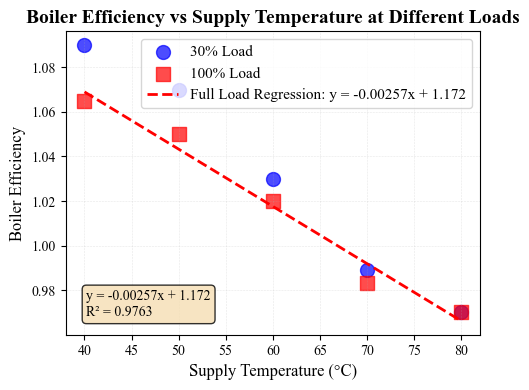


Regression Details (Full Load):
Coefficient (slope): -0.002570
Intercept: 1.171800
R² Score: 0.976305


In [6]:


# Data from the table
temperatures = np.array([40, 50, 60, 70, 80])  # Temperature (°C)
efficiency_30 = np.array([1.09, 1.07, 1.03, 0.989, 0.97])
efficiency_100 = np.array([1.065, 1.05, 1.02, 0.983, 0.97])

# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 4))

# Plot scatter points
ax.scatter(temperatures, efficiency_30, color='blue', s=100, 
           label='30% Load', alpha=0.7, marker='o')
ax.scatter(temperatures, efficiency_100, color='red', s=100, 
           label='100% Load', alpha=0.7, marker='s')

# Perform linear regression for full load (100%)
# Reshape temperatures for sklearn
X = temperatures.reshape(-1, 1)
y = efficiency_100

# Create and fit linear regression model
regressor = LinearRegression()
regressor.fit(X, y)

# Generate points for regression line
temp_range = np.linspace(temperatures.min(), temperatures.max(), 100)
predicted_efficiency = regressor.predict(temp_range.reshape(-1, 1))

# Plot regression line
ax.plot(temp_range, predicted_efficiency, color='red', 
        linestyle='--', linewidth=2, 
        label=f'Full Load Regression: y = {regressor.coef_[0]:.5f}x + {regressor.intercept_:.3f}')

# Add labels and title
ax.set_xlabel('Supply Temperature (°C)', fontsize=12)
ax.set_ylabel('Boiler Efficiency', fontsize=12)
ax.set_title('Boiler Efficiency vs Supply Temperature at Different Loads', 
             fontsize=14, fontweight='bold')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(fontsize=11, loc='best')

# Add equation text box
equation_text = f'y = {regressor.coef_[0]:.5f}x + {regressor.intercept_:.3f}\nR² = {regressor.score(X, y):.4f}'
ax.text(0.05, 0.05, equation_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Ensure directory exists
os.makedirs('data/inputs', exist_ok=True)

# Save figure as PDF
output_path = 'data/inputs/boiler_efficiency.pdf'
plt.tight_layout()
plt.savefig(output_path, format='pdf', dpi=300)
print(f"Figure saved to: {output_path}")

# Show the plot
plt.show()

# Print regression details
print("\nRegression Details (Full Load):")
print(f"Coefficient (slope): {regressor.coef_[0]:.6f}")
print(f"Intercept: {regressor.intercept_:.6f}")
print(f"R² Score: {regressor.score(X, y):.6f}")